**Softmax**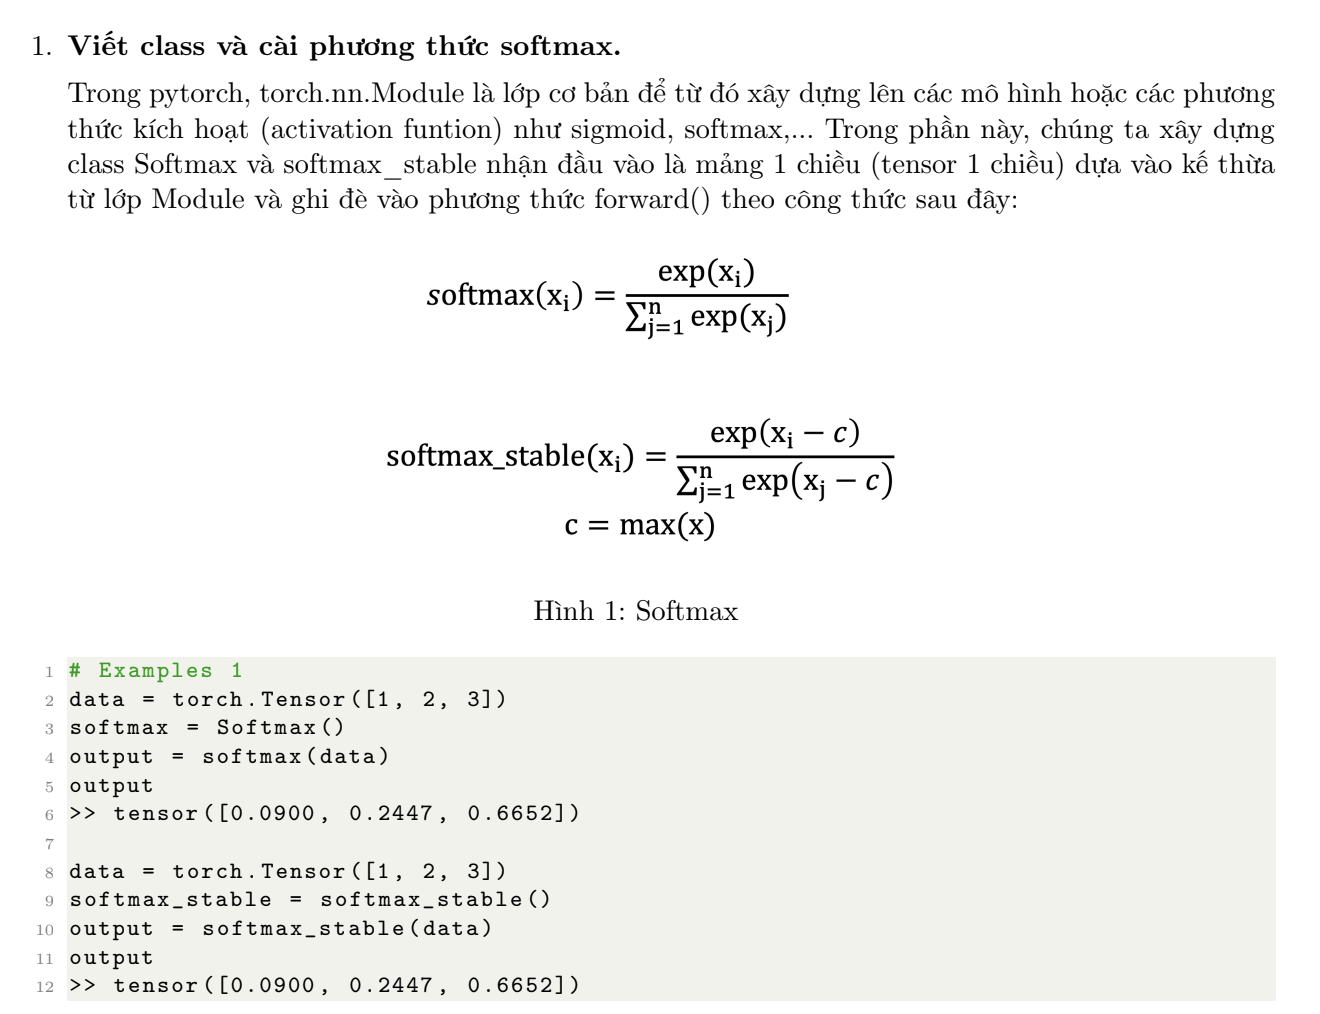

In [1]:
import torch
import torch.nn as nn

ModuleNotFoundError: No module named 'torch'

In [ ]:
data = torch.Tensor([1, 2, 3])
data


tensor([1., 2., 3.])

In [ ]:
softmax_function = nn.Softmax(dim = 0)
output = softmax_function(data)
output

tensor([0.0900, 0.2447, 0.6652])

In [ ]:
class MySoftMax(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    x_exp = torch.exp(x)
    total = x_exp.sum(0, keepdims=True)
    return x_exp / total

my_softmax = MySoftMax()
output = my_softmax(data)
output

tensor([0.0900, 0.2447, 0.6652])

In [ ]:
data = torch.Tensor([1, 2, 3000000000])
data

tensor([1.0000e+00, 2.0000e+00, 3.0000e+09])

In [ ]:
my_softmax = MySoftMax()
output = my_softmax(data)
output

tensor([0., 0., nan])

In [ ]:
class StableSoftMax(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    c = torch.max(x, dim = 0)
    x_exp = torch.exp(x - c.values)
    total = x_exp.sum(0, keepdims = True)
    return x_exp / total

stable_softmax = StableSoftMax()
output = stable_softmax(data)
output


tensor([0., 0., 1.])

# **Exercise 2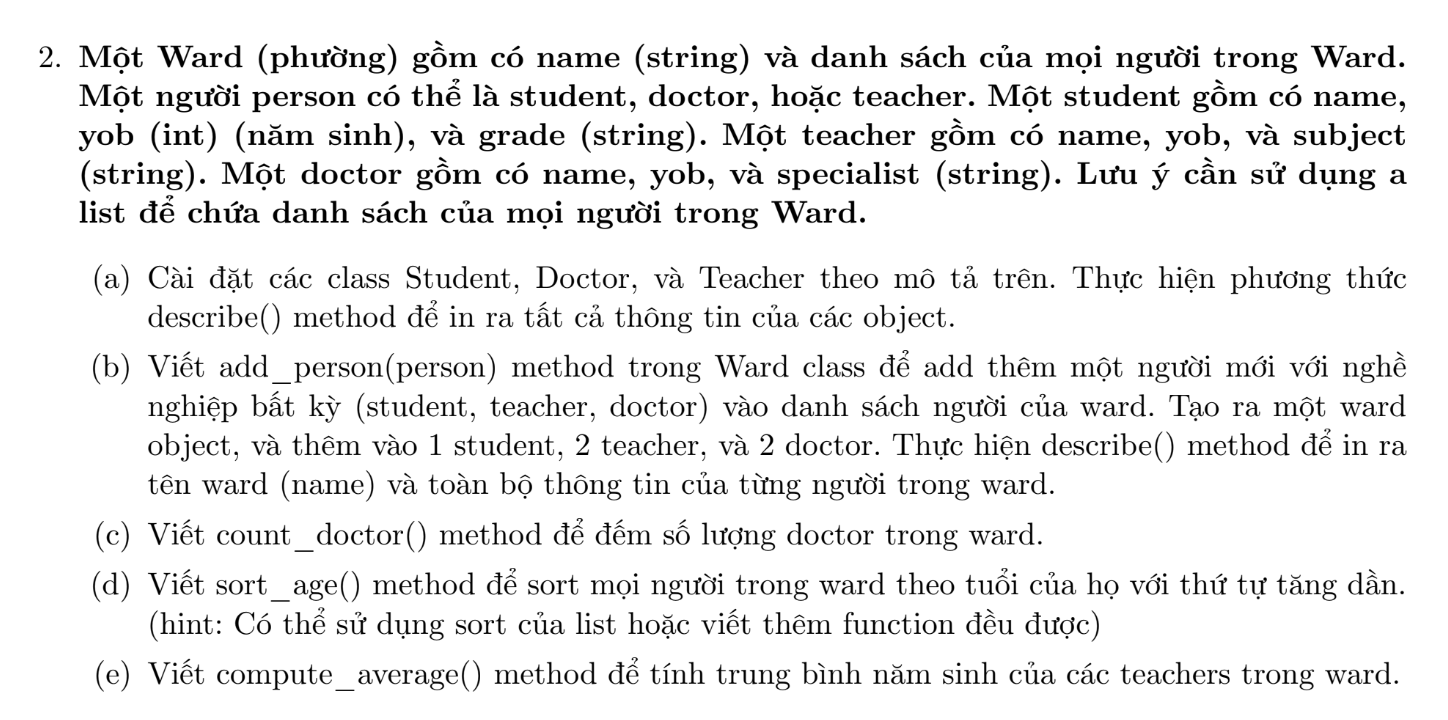**

In [ ]:
class Person():
  def __init__(self, name, yob):
    self._name = name
    self._yob = yob
  def describe(self):
    pass

class Student(Person):
  def __init__(self, name, yob, grade):
    super().__init__(name, yob)
    self._grade = grade
  def describe(self):
    print(f'Student - Name: {self._name} - Yob: {self._yob} - Grade: {self._grade}')

class Teacher(Person):
  def __init__(self, name, yob, subject):
    super().__init__(name, yob)
    self._subject = subject
  def describe(self):
    print(f'Teacher - Name: {self._name} - Yob: {self._yob} - Subject: {self._subject}')

class Doctor(Person):
  def __init__(self, name, yob, specialist):
    super().__init__(name, yob)
    self._specialist = specialist
  def describe(self):
    print(f'Doctor - Name: {self._name} - Yob: {self._yob} - Specialist: {self._specialist}')

class Ward():
  def __init__(self, name):
    self.__name = name
    self.__list_people = []

  def add_person(self, person):
    self.__list_people.append(person)

  def describe(self):
    print(f'Ward Name: {self.__name}')
    for p in self.__list_people:
      p.describe()

  def count_doctor(self):
    count = 0
    for p in self.__list_people:
      if isinstance(p, Doctor):
        count += 1
    return count

  def sort_age(self):
    self.__list_people.sort(key=lambda x: x._yob, reverse=True)
    return self.__list_people

  def compute_avg_age_teacher(self):
    total_age = 0
    count = 0
    for p in self.__list_people:
      if isinstance(p, Teacher):
        age = 2026 - p._yob
        total_age += age
        count += 1
    if count == 0:
      return 0
    return total_age / count


In [ ]:
# --- RUN TEST CASE ---

# 1. Tạo một Ward tên là "Ward1"
ward1 = Ward("Ward1")

# 2. Tạo các object con người
student1 = Student(name="studentA", yob=2010, grade="7")

teacher1 = Teacher(name="teacherA", yob=1969, subject="Math")
teacher2 = Teacher(name="teacherB", yob=1995, subject="History")

doctor1 = Doctor(name="doctorA", yob=1945, specialist="Endocrinologists")
doctor2 = Doctor(name="doctorB", yob=1975, specialist="Cardiologists")

# 3. Thêm mọi người vào Ward (1 Student, 2 Teacher, 2 Doctor)
ward1.add_person(student1)
ward1.add_person(teacher1)
ward1.add_person(teacher2)
ward1.add_person(doctor1)
ward1.add_person(doctor2)

# 4. In thông tin Ward để kiểm tra
ward1.describe()
# Dem doctor
print(f'Number of doctor: {ward1.count_doctor()}')

avg_age = ward1.compute_avg_age_teacher()
print(f'Avg age of teacher: {avg_age}')

Ward Name: Ward1
Student - Name: studentA - Yob: 2010 - Grade: 7
Teacher - Name: teacherA - Yob: 1969 - Subject: Math
Teacher - Name: teacherB - Yob: 1995 - Subject: History
Doctor - Name: doctorA - Yob: 1945 - Specialist: Endocrinologists
Doctor - Name: doctorB - Yob: 1975 - Specialist: Cardiologists
Number of doctor: 2
Avg age of teacher: 44.0


# **Exercise 3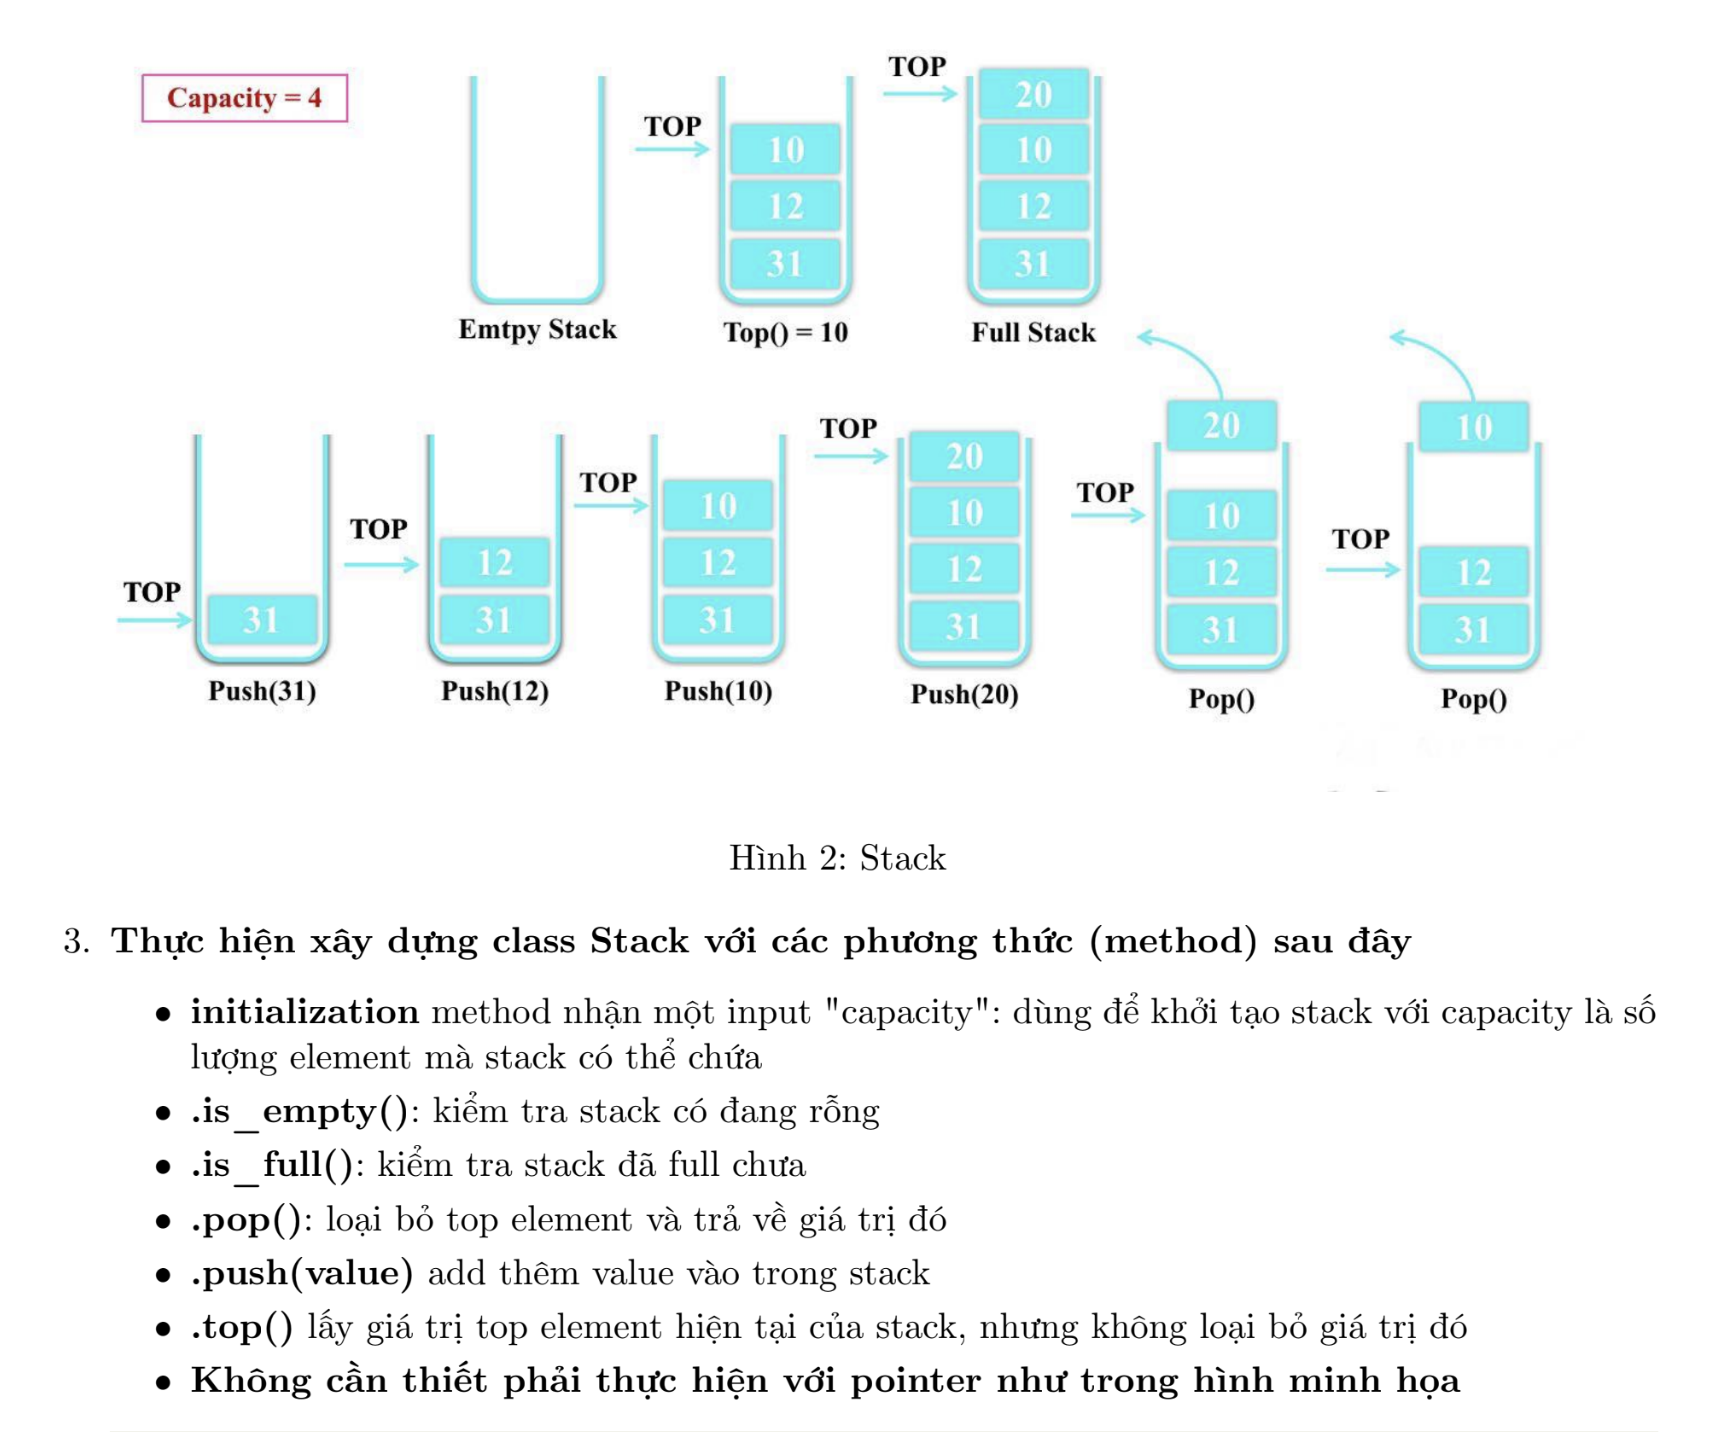**

In [ ]:
class Stack():
  def __init__(self, capacity):
    self.capacity = capacity
    self.items = []

  def is_empty(self):
    if len(self.items) == 0:
      return True
    else:
      return False

  def is_full(self):
    if len(self.items) == self.capacity:
      return True
    else:
      return False

  def pop(self):
    if self.is_empty():
      print('Stack is empty')
      return None
    else:
      return self.items.pop()

  def push(self, value):
    if self.is_full():
      print('Stack is full')
    else:
      self.items.append(value)

  def top(self):
    if self.is_empty():
      print('Stack is empty')
      return None
    else:
      return self.items[-1]





In [ ]:
stack1 = Stack(capacity = 5)
stack1.push(1)
stack1.push(2)
print(stack1.is_full())
print(stack1.top())
print(stack1.pop())
print(stack1.top())
print(stack1.pop())
print(stack1.is_empty())

False
2
2
1
1
True


# **Queue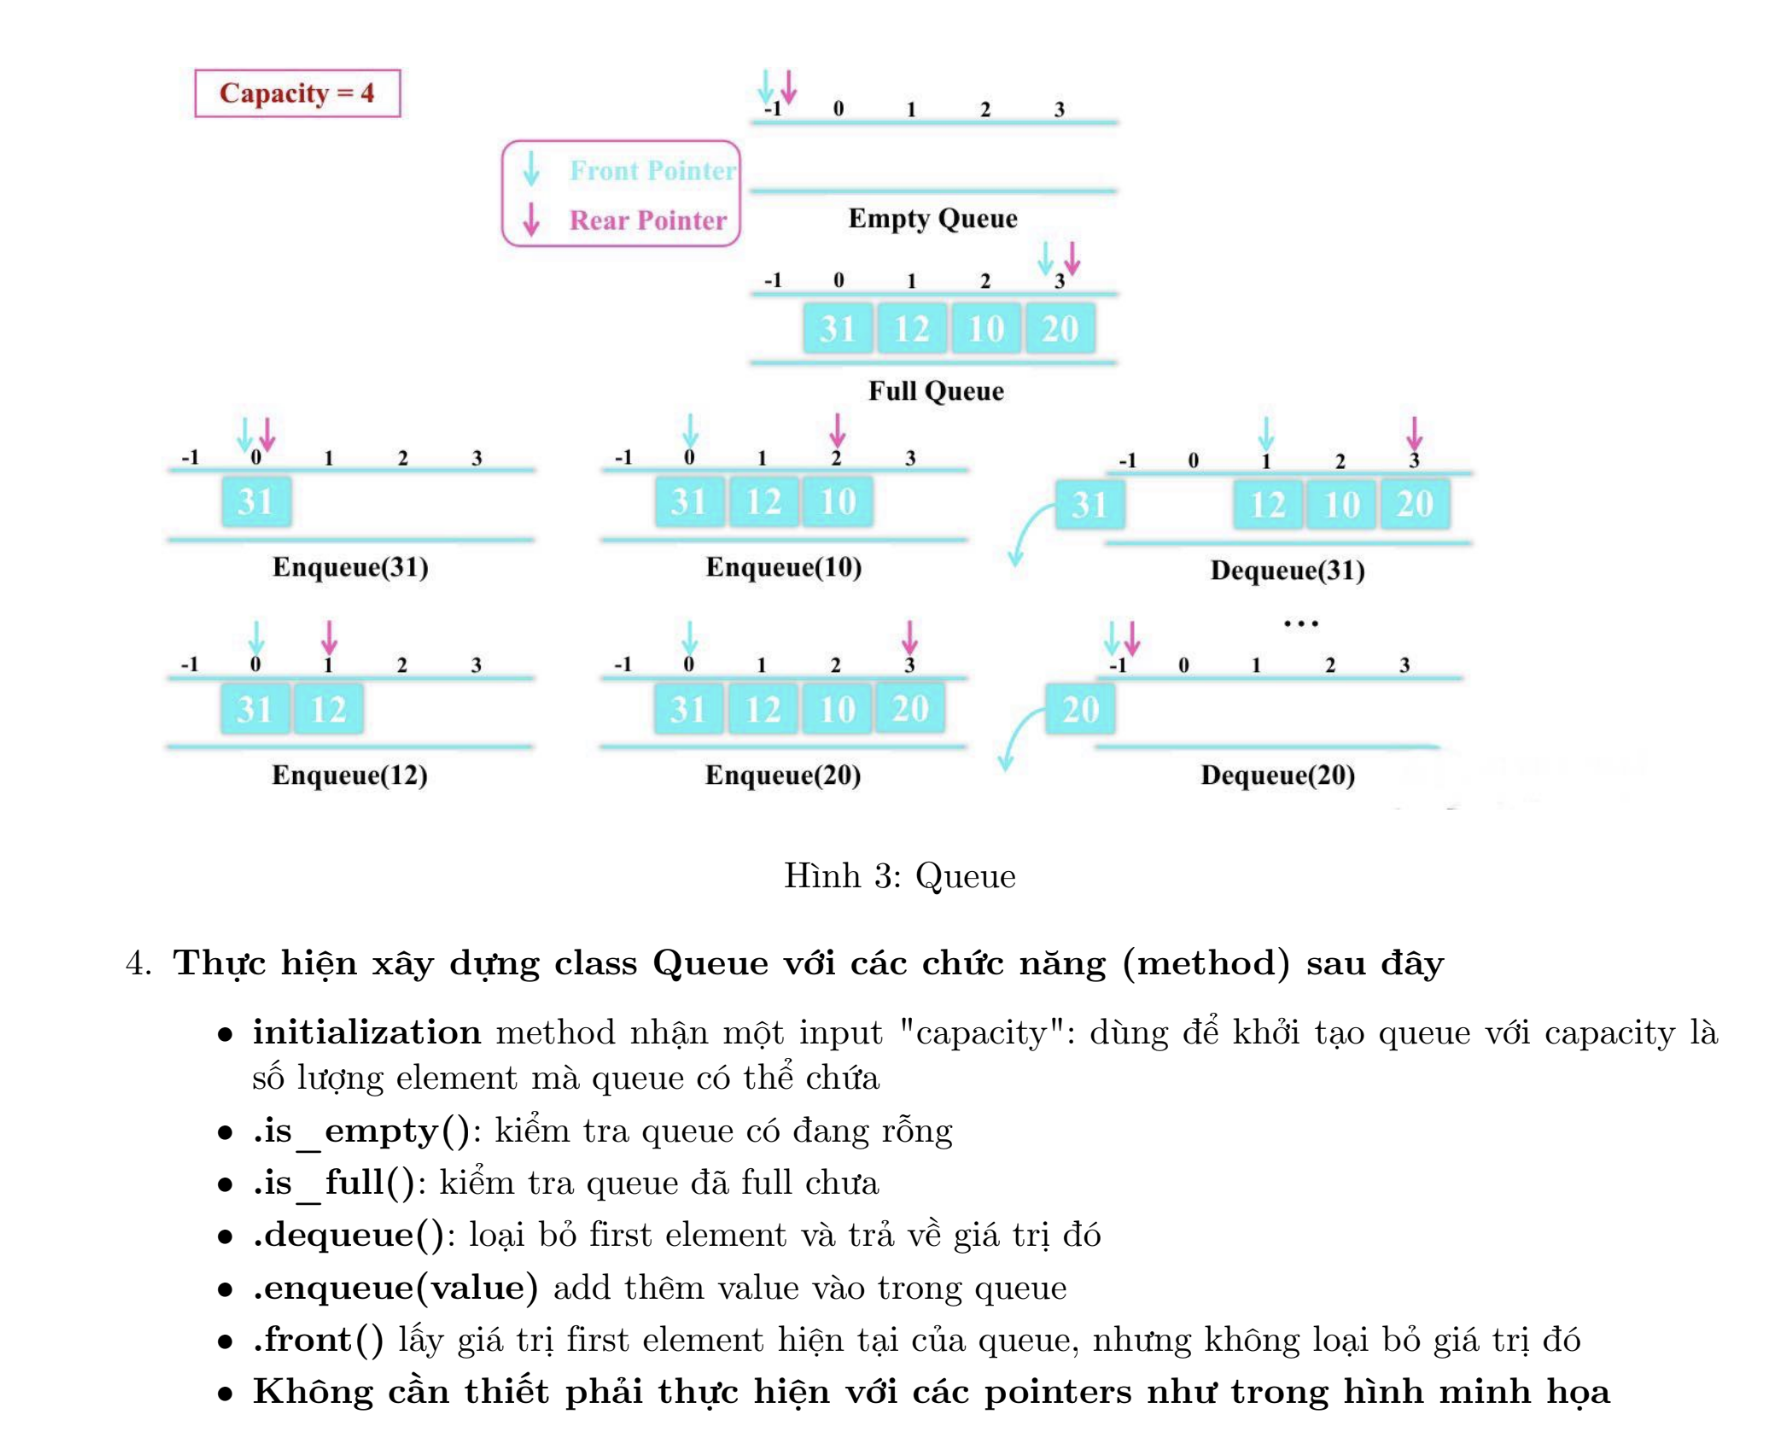**

In [ ]:
class Queue():
  def __init__(self, capacity):
    self.capacity = capacity
    self.items = []

  def is_empty(self):
    if len(self.items) == 0:
      return True
    else:
      return False

  def is_full(self):
    if len(self.items) == self.capacity:
      return True
    else:
      return False

  def enqueue(self, value):
    if self.is_full():
      print('Queue is full')
    else:
      self.items.append(value)

  def dequeue(self):
    if self.is_empty():
      print('Queue is empty')
    else:
      return self.items.pop(0)

  def front(self):
    if self.is_empty():
      print('Queue is empty')
      return None
    else:
      return self.items[0]